# Antibunching

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc
import src.figure as fi

import numpy as np

%load_ext autoreload
%autoreload 2

C:\Users\SagixOffice\miniconda3\envs\markovmodels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


In [2]:
number_fluorophores = 3
distance = 18
remove_transitions = ['OFRET', 'HFRET', 'CFRET', 'TFRET', 'ETT', 'ETS', 'REDT', 'REDS']
fluorophores = fl.construct_fluorophores('cy5', distance, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = tr.load_transitions(fluorophore_system, irradiance=2.5, wavelength=640, bleaching=False)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
transition_set.finalize()

In [195]:
simulation = si.Simulation(transition_set)
simulation.run(size=int(5e7), end_time=None, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='1s', emccd_gain=None, seed=4)

array([[<AxesSubplot:title={'center':'$\\tau_{min} = 1.39e-13$ s'}, xlabel='$\\tau \\ [s]$', ylabel='$G(\\tau)$'>]],
      dtype=object)

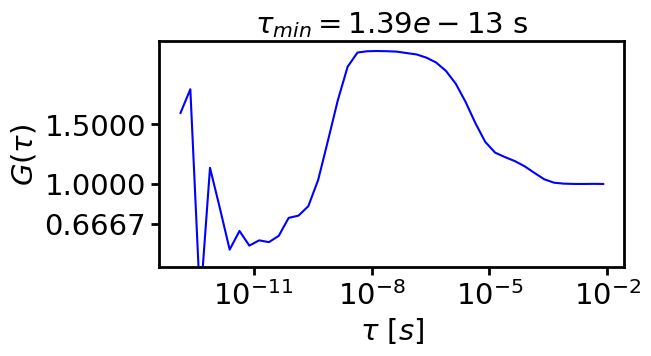

In [197]:
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-13, exp_max=-2)
fcs.plot(ylim=[0.3, 2.2], yticks=[2/3, 1, 1.5])

In [187]:
number_fluorophores = 2
distance = 18
remove_transitions = ['OFRET', 'HFRET', 'CFRET', 'TFRET', 'ETT', 'ETS', 'REDT', 'REDS']
fluorophores = fl.construct_fluorophores('cy5', distance, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = tr.load_transitions(fluorophore_system, irradiance=2.5, wavelength=640, bleaching=False)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
transition_set.finalize()

In [198]:
simulation = si.Simulation(transition_set)
simulation.run(size=int(5e7), end_time=None, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='1s', emccd_gain=None, seed=4)

array([[<AxesSubplot:title={'center':'$\\tau_{min} = 1.39e-12$ s'}, xlabel='$\\tau \\ [s]$', ylabel='$G(\\tau)$'>]],
      dtype=object)

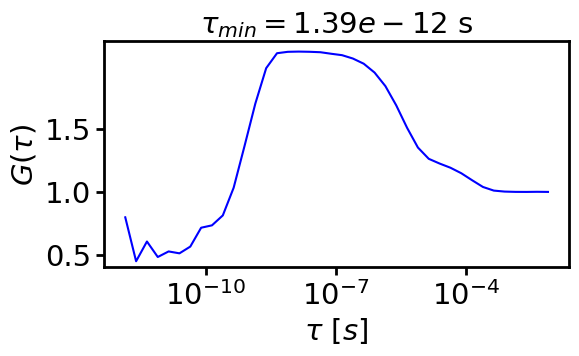

In [199]:
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-12, exp_max=-2)
fcs.plot(ylim=[0.4, 2.2], yticks=[0.5, 1, 1.5])

In [200]:
number_fluorophores = 1
distance = 18
remove_transitions = ['OFRET', 'HFRET', 'CFRET', 'TFRET', 'ETT', 'ETS', 'REDT', 'REDS']
fluorophores = fl.construct_fluorophores('cy5', distance, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = tr.load_transitions(fluorophore_system, irradiance=2.5, wavelength=640, bleaching=False)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
transition_set.finalize()

In [201]:
simulation = si.Simulation(transition_set)
simulation.run(size=int(5e7), end_time=None, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='1s', emccd_gain=None, seed=4)

array([[<AxesSubplot:title={'center':'$\\tau_{min} = 1.39e-12$ s'}, xlabel='$\\tau \\ [s]$', ylabel='$G(\\tau)$'>]],
      dtype=object)

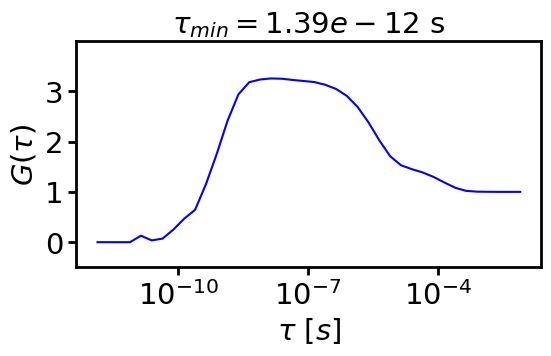

In [205]:
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-12, exp_max=-2)
fcs.plot(ylim=[-0.5, 4], yticks=[0, 1, 2, 3])

---

In [4]:
number_fluorophores = 3
distance = 18
remove_transitions = ['OFRET', 'HFRET', 'CFRET', 'TFRET', 'ETT', 'ETS', 'REDT', 'REDS']
fluorophores = fl.construct_fluorophores('cy5', distance, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = tr.load_transitions(fluorophore_system, irradiance=2.5, wavelength=640, bleaching=False)
singlet_singlet_annihilation = tr.Transition(tr.TransitionType.S_S_ANNIHILATION, 1e9, 18)
transitions.append(singlet_singlet_annihilation)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
transition_set.finalize()

In [5]:
transition_set.transition_df

,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance
id,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,7.269626e+06,False,False,NaN
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,2.700000e+08,True,False,NaN
2,TransitionType.INTERSYSTEM_CROSSING_ST,ISCST,SingleState.S1,SingleState.T1,8.300000e+05,False,False,NaN
3,TransitionType.INTERSYSTEM_CROSSING_TS,ISCTS,SingleState.T1,SingleState.S0,5.000000e+03,False,False,NaN
4,TransitionType.ISOMERIZATION,ISO,SingleState.S1,SingleState.Cis,2.000000e+07,False,False,NaN
5,TransitionType.BACKISOMERIZATION,BISO,SingleState.Cis,SingleState.S0,1.369280e+05,False,False,NaN
6,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,7.091700e+08,False,False,NaN
7,TransitionType.OXIDATION,OXI,SingleState.OFF,SingleState.S0,2.000000e-02,False,False,NaN
8,TransitionType.S_S_ANNIHILATION,SSA(18.0),PairedState.S1_S1,PairedState.S0_S1,1.000000e+09,False,True,18.0


In [6]:
simulation = si.Simulation(transition_set)
simulation.run(size=int(5e7), end_time=None, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='1s', emccd_gain=None, seed=4)

array([[<AxesSubplot:title={'center':'$\\tau_{min} = 1.39e-13$ s'}, xlabel='$\\tau \\ [s]$', ylabel='$G(\\tau)$'>]],
      dtype=object)

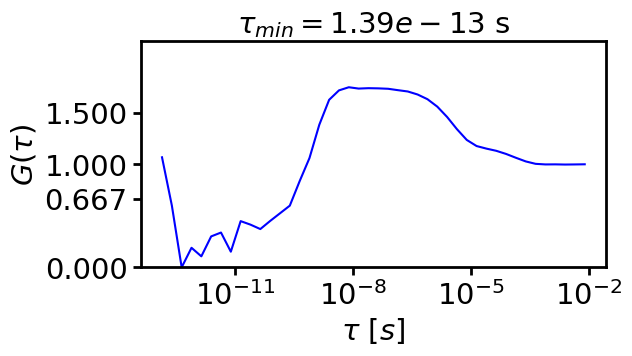

In [11]:
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-13, exp_max=-2)
fcs.plot(ylim=[0, 2.2], yticks=[0, 2/3, 1, 1.5])

In [21]:
number_fluorophores = 3
distance = 18
remove_transitions = ['OFRET', 'HFRET', 'CFRET', 'TFRET', 'ETT', 'ETS', 'REDT', 'REDS']
fluorophores = fl.construct_fluorophores('cy5', distance, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = tr.load_transitions(fluorophore_system, irradiance=2.5, wavelength=640, bleaching=False)
singlet_singlet_annihilation = tr.Transition(tr.TransitionType.S_S_ANNIHILATION, 1e10, 18)
transitions.append(singlet_singlet_annihilation)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
transition_set.finalize()

In [14]:
simulation = si.Simulation(transition_set)
simulation.run(size=int(5e7), end_time=None, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='1s', emccd_gain=None, seed=4)

array([[<AxesSubplot:title={'center':'$\\tau_{min} = 1.39e-13$ s'}, xlabel='$\\tau \\ [s]$', ylabel='$G(\\tau)$'>]],
      dtype=object)

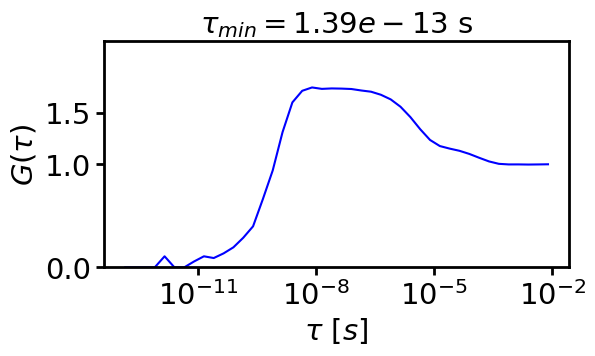

In [15]:
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-13, exp_max=-2)
fcs.plot(ylim=[0, 2.2], yticks=[0, 1, 1.5])

---

In [34]:
number_fluorophores = 3
distance = 18
remove_transitions = ['OFRET', 'CFRET', 'TFRET', 'ETT', 'ETS', 'REDT', 'REDS']
fluorophores = fl.construct_fluorophores('cy5', distance, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = tr.load_transitions(fluorophore_system, irradiance=2.5, wavelength=640, bleaching=False)[:7]
hfret = tr.Transition(tr.TransitionType.HOMO_FRET, 1e9, 18)
transitions.append(hfret)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
transition_set.finalize()

In [35]:
transition_set.transition_df

,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance
id,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,7.269626e+06,False,False,NaN
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,2.700000e+08,True,False,NaN
2,TransitionType.INTERSYSTEM_CROSSING_ST,ISCST,SingleState.S1,SingleState.T1,8.300000e+05,False,False,NaN
3,TransitionType.INTERSYSTEM_CROSSING_TS,ISCTS,SingleState.T1,SingleState.S0,5.000000e+03,False,False,NaN
4,TransitionType.ISOMERIZATION,ISO,SingleState.S1,SingleState.Cis,2.000000e+07,False,False,NaN
5,TransitionType.BACKISOMERIZATION,BISO,SingleState.Cis,SingleState.S0,1.369280e+05,False,False,NaN
6,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,7.091700e+08,False,False,NaN
7,TransitionType.HOMO_FRET,HFRET(18.0),PairedState.S1_S0,PairedState.S0_S1,1.000000e+09,False,True,18.0


In [36]:
simulation = si.Simulation(transition_set)
simulation.run(size=int(5e7), end_time=None, seed=3)
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='1s', emccd_gain=None, seed=4)

array([[<AxesSubplot:title={'center':'$\\tau_{min} = 1.39e-13$ s'}, xlabel='$\\tau \\ [s]$', ylabel='$G(\\tau)$'>]],
      dtype=object)

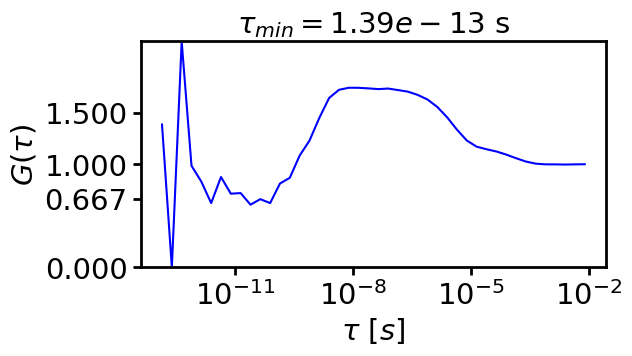

In [38]:
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-13, exp_max=-2)
fcs.plot(ylim=[0, 2.2], yticks=[0, 2/3, 1, 1.5])

In [ ]:
"""
Module antibunching
Basically the same as autocorrelation but methodically closer to the Hanbury Brown and Twiss
experiment.
"""
import numpy as np
import pycorrelate as pc
import src.figure as fi
import pandas as pd


def hanbury_brown_twiss(simulation, seed, exp_min, exp_max, points_per_base, base, normalize):
    """
    Creates two photon detection channels and correlates them.
        
    Parameters
    ----------
    simulation : src.simulation.Simulation
        Container of simulation-associated attributes and methods.
    seed : None, int, BitGenerator, Generator
        A seed to initialize the BitGenerator.
    exp_min : int
        Exponent of the minimum value.
    exp_max : int
        Exponent of the maximum value.
    points_per_base : int
        Number of points per base.
    base : int
        The base of the exponentiation.
    normalize : bool
        Whether to normalize the autocorrelation.

    Returns
    -------
    correlation : 1-D array_like
        Correlation values
    tau : 1-D array_like
        Time differences
    """
    rng = np.random.default_rng(seed)
    emission_indices = get_emission_indices()
    rng.shuffle(emission_indices)
    
    first_channel = np.sort(simulation.time_series[emission_indices[:int(emission_indices.size/2)]])
    second_channel = np.sort(simulation.time_series[emission_indices[int(emission_indices.size/2):]])

    if base ** exp_max > first_channel[-1]:
        raise ValueError('Base to the power of exp_max cannot be larger than the last time point.')
    bins = pc.make_loglags(exp_min=exp_min, exp_max=exp_max, points_per_base=points_per_base, base=base)
    correlation = pc.pcorrelate(t=first_channel, u=second_channel, bins=bins, normalize=normalize)
    tau = np.mean([bins[1:], bins[:-1]], 0)

    return correlation, tau


def plot(tau, correlation, normalize_to=None, unit='s', **kwargs):
    """
    Plot correlation data.

    Parameters
    ----------
    tau : 1-D array_like
        Time differences
    correlation : 1-D array_like
        Correlation values
    normalize_to : None, int
        Index of datapoint to which the data is normalized.
    unit : str
        One of 's', 'ms', 'us'. Influences the unit of the x-axis.
    kwargs : src.figure.universal_figure arguments

    Returns
    -------
    axes : np.ndarray
        Contains matplotlib.axes._subplots.AxesSubplots.
    """
    tau_data, correl_data = np.copy(tau), np.copy(correlation)
    if normalize_to is not None:
        correl_data /= correl_data[normalize_to]

    adjust_unit = pd.to_timedelta(1, unit=unit).total_seconds()
    tau_data = tau_data / adjust_unit
    kwargs.setdefault('title', rf"$\tau_{{min}} = {tau_data[0]:.2e}$ {unit}")
    kwargs.setdefault('type_', "line")
    kwargs.setdefault('xscale', "log")
    kwargs.setdefault('xlabel', fr"$\tau \ [{unit}]$")
    kwargs.setdefault('ylabel', r"$G(\tau)$")

    axes = fi.universal_figure(data=[tau_data, correl_data], **kwargs)

    return axes


def get_emission_indices(simulation):
    """
    Get indices to apply to simulation.transition_series to yield emitting transitions.

    Parameters
    ----------
    simulation : src.simulation.Simulation
        Container of simulation-associated attributes and methods.

    Returns
    -------
    emission_indices : 1-D array_like
        Indices of emitting transitions to apply to simulation.transition_series.
    """
    df = simulation.transition_set.combined_state_transitions_df
    emitting_transition_ids = df.loc[df['photon'] == True].index.to_numpy()
    emission_indices = np.in1d(simulation.transition_series, emitting_transition_ids).nonzero()[0]

    return emission_indices
